In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy
from time import perf_counter

``` Pseudocode Algorithm
Algorithm: baseline_max_sublist(A)
Input: A list A of n integers
Output: The maximum contiguous subarray sum

1. max_so_far = negative infinity
2. for i from 0 to n-1:
3.    sum = 0
4.    for j from i to n-1:
5.       sum = A[j] + sum
6.       if sum > max_so_far:
7.          max_so_far = sum
8. return max_so_far

```

In [56]:
# Implement baseline algorithm
def baseline_max_sublist(arr):
    n = len(arr)
    max_so_far = -9999999999999999999999999999999999999999999999999999999999999999999999
    for i in range(0,n):
        sum = 0
        for j in range(i,n):
            sum += arr[j]
            if sum > max_so_far:
                max_so_far = sum
    return max_so_far

print(baseline_max_sublist([-2, 1, -3, 4, -1, 2, 1, -5, 4]))

6


In [57]:
# Implement target algorithm
def kadane_max_sublist(arr):
    n = len(arr)
    max_so_far = -9999999999999999999999999999999999999999999999999999999999999999999999
    current_max = 0
    for i in range(0,n-1):
        current_max += arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        if current_max < 0:
            current_max = 0
    return max_so_far

print(kadane_max_sublist([-2, 1, -3, 4, -1, 2, 1, -5, 4]))

6


In [58]:
# helper function
def helper_function(n):
    random_list = []
    for i in range(n):
        random_list.append(numpy.random.randint(-100, 101))
    return random_list

print(helper_function(5))

def helper_function_lists(n):
    random_list = []
    for i in n:
        random_list.append(helper_function(i))
    return random_list

print(helper_function_lists(abs(number) for number in helper_function(5)))



[34, -99, 46, -77, 41]
[[-12, -80, -43, -1, -24, 36, 70, 65, -57, 13, -33, 54, -47, -44, 39, -26, -30, 53, -74, 29, 72, 92, 20, -71, -29, -33, -38, 98, 11, 12, -8, -80, -80, -39, -95, -41, -76, 23, -42, 37, -61, -16, -7, 18, 63, 28, 47, -61, 44, 42, 9, -79, 54, -4, -45, -24, 17, 65, -66, 49, 28, -56, -11, -94, -37, -97, -63, -91, -63, -94, -73, 68, -49, 30, 87, -48, -43, 65, 33, 5, -64, 37, 38, 55, -24, -55, 30, -72, -68, -85, -84, 45, -59, 3, 69, -63, -64, -15, -61, -67], [-87, 16, -64, 42, 45, 80, 55, 59, -60, -61, 40, 19, -47, 77], [100, -71, 47, 58, 84, 73, 70, 18, -48, 17, -61, -57, 48, 91, 10, 77, -91, 46, -44, 7, -87, -77, -44, -69, -86, 49, -68, 92, 72, -21, -23, 38, 73, 57, 66, 37, 82, 95, -87, 24, -22, -26, -32, 79, -32, 28, 7, 72, 17, -46, 19, -77, 50, 40, -80, -81, -78, -21, -88, 54, -63, -5, 27, 88, 62, -32, 75, -30, -45, 96, 19, 21, 76, -86], [-22, -18, -45, -64, 50, -30, -80, 20, 79, 2, -30, 97, -24, 71, 42, -74, -78, 81, 95, 36, -38, 87, 23, 12, -51, 94, -95, -84, -35, 

baseline: [(100, 0.0002627633046358824), (500, 0.008678816183237358), (1000, 0.03545079940813593), (2500, 0.21596100750612096), (5000, 0.8776630963024218), (10000, 3.5411395951057782)]
kadane: [(100, 7.884792285040022e-06), (500, 3.4841190790757536e-05), (1000, 7.388928788714111e-05), (2500, 0.00018266270053572952), (5000, 0.0003777329984586686), (10000, 0.0007787534908857196)]


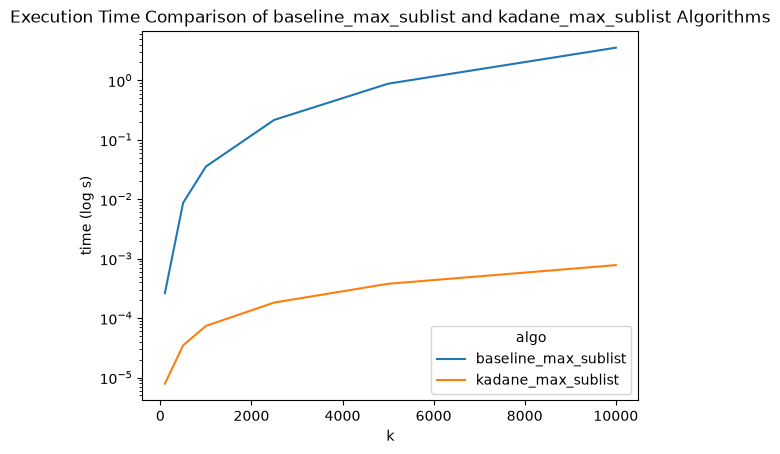

In [ ]:
# benchmarking
baseline_times = []
kadane_times = []

def benchmark_algo_multi(algo, test_cases, repeat=1):
    times = []
    for i in test_cases:
        total_duration = 0
        for _ in range(repeat):
            start = perf_counter()
            algo(i)
            end = perf_counter()
            duration = end - start
            total_duration += duration
        avg_time = total_duration / repeat
        times.append((len(i), avg_time))
    return times

repeats = [100, 500, 1000, 2500, 5000, 10000]
baseline_max_sublist_times = benchmark_algo_multi(baseline_max_sublist, helper_function_lists(repeats), 10)
kadane_max_sublist_times = benchmark_algo_multi(kadane_max_sublist, helper_function_lists(repeats), 10)

print(f"baseline: {baseline_max_sublist_times}")
print(f"kadane: {kadane_max_sublist_times}")

df_base = pd.DataFrame(baseline_max_sublist_times, columns = ["k", "time"])
df_base['algo'] = "baseline_max_sublist"

df_kadane = pd.DataFrame(kadane_max_sublist_times, columns = ["k", "time"])
df_kadane['algo'] = "kadane_max_sublist"

df = pd.concat([df_base, df_kadane], ignore_index=True)

sns.lineplot(data=df, x="k", y="time", hue="algo")
plt.xlabel("k")
plt.ylabel("time (log s)")
plt.title("Execution Time Comparison of baseline_max_sublist and kadane_max_sublist Algorithms")
plt.show()
